# 02 — Match the benchmark chart, then predict

**The philosophy (important):** we do NOT tune numbers until our line
matches the target — that would be overfitting: a factor that "fits"
history but means nothing. Instead:

1. The benchmark chart is used **only as a checker** — a scorecard.
2. What we vary is the **method**: a short menu of equally-defensible
   readings of "21 day exponentially weighted z-score" (halflife vs span
   vs center-of-mass, z-score of level vs of change, WTI vs Brent).
   Every candidate is a sensible construction on its own.
3. Weights stay **equal (1/6)** — that IS the method. We run a weight
   fit only as a *diagnostic*: if it confirms ~1/6 everywhere, good;
   if it demands extreme weights to fit, that's a red flag, not a result.

Then: decomposition, an extended AR(1) forecast, and a `live_refresh()`
you can run any day to pull data up to today and extrapolate forward.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg
import factor_lib as fl

if bbg.MOCK_MODE:
    print("MOCK MODE - method scores vs the real benchmark are meaningless")
    print("here; run with Bloomberg data for the scores to mean something.")

MOCK MODE - method scores vs the real benchmark are meaningless
here; run with Bloomberg data for the scores to mean something.


### Part A — the benchmark trace (digitized from the chart image)

We read the target chart off its image by eye into (date, value) anchor
points, then interpolate to business days. It is deliberately coarse —
a checker doesn't need to be perfect, just faithful in shape and level.

**These anchors are approximate.** With the image open next to this cell,
adjusting any point takes seconds — refine them whenever a region of the
chart matters to you.

In [2]:
ANCHORS = [
    # 2025 H1
    ("2025-01-02", 0.25), ("2025-01-08", 0.60), ("2025-01-14", -0.10),
    ("2025-01-21", 0.35), ("2025-01-28", -0.50), ("2025-02-04", 0.30),
    ("2025-02-11", -0.70), ("2025-02-18", -1.90), ("2025-02-25", -1.20),
    ("2025-03-04", -0.30), ("2025-03-11", 0.40), ("2025-03-18", -0.80),
    ("2025-03-25", -0.20), ("2025-04-01", 0.50), ("2025-04-08", 1.15),
    ("2025-04-15", 2.05), ("2025-04-22", 1.50), ("2025-04-29", 0.70),
    ("2025-05-06", 1.30), ("2025-05-13", 0.50), ("2025-05-20", 1.00),
    ("2025-05-27", 0.30), ("2025-06-03", 0.80), ("2025-06-10", 0.20),
    ("2025-06-17", 0.60), ("2025-06-24", -0.20),
    # 2025 H2
    ("2025-07-01", 0.50), ("2025-07-08", -0.90), ("2025-07-15", 0.30),
    ("2025-07-22", 0.70), ("2025-07-29", 0.10), ("2025-08-05", 0.60),
    ("2025-08-12", -0.50), ("2025-08-19", 1.70), ("2025-08-26", 1.50),
    ("2025-09-02", 0.90), ("2025-09-09", 0.40), ("2025-09-16", 0.80),
    ("2025-09-23", -0.10), ("2025-09-30", 0.30), ("2025-10-07", -0.70),
    ("2025-10-14", -1.60), ("2025-10-21", -0.90), ("2025-10-28", -0.30),
    ("2025-11-04", 0.50), ("2025-11-11", -0.40), ("2025-11-18", -1.70),
    ("2025-11-25", -0.80), ("2025-12-02", 0.40), ("2025-12-09", 1.10),
    ("2025-12-16", 1.80), ("2025-12-23", 1.60), ("2025-12-30", 1.00),
    # 2026
    ("2026-01-06", 1.85), ("2026-01-13", 1.30), ("2026-01-20", 1.60),
    ("2026-01-27", 0.60), ("2026-02-03", 0.40), ("2026-02-10", 0.90),
    ("2026-02-17", -0.20), ("2026-02-24", 0.50), ("2026-03-03", -0.90),
    ("2026-03-10", -1.65), ("2026-03-17", -0.40), ("2026-03-24", 0.20),
    ("2026-03-31", -0.60), ("2026-04-07", 0.60), ("2026-04-14", 1.20),
    ("2026-04-21", 0.40), ("2026-04-28", 0.90), ("2026-05-05", -0.60),
    ("2026-05-12", 0.20), ("2026-05-19", 1.20), ("2026-05-26", 0.80),
    ("2026-06-02", 0.50), ("2026-06-09", 1.00), ("2026-06-16", 0.90),
    # the June FOMC spike and unwind
    ("2026-06-18", 1.60), ("2026-06-22", 2.05), ("2026-06-24", 1.70),
    ("2026-06-26", 1.95), ("2026-06-30", 1.60), ("2026-07-02", 0.90),
    ("2026-07-06", 0.40), ("2026-07-08", -0.05),
]

anchor_series = pd.Series({pd.Timestamp(d): v for d, v in ANCHORS})
bdays = pd.bdate_range(anchor_series.index[0], anchor_series.index[-1])
benchmark = anchor_series.reindex(bdays).interpolate(method="time")
benchmark.name = "benchmark"
print(f"Benchmark trace: {len(benchmark)} business days, "
      f"{benchmark.index[0].date()} to {benchmark.index[-1].date()}")

Benchmark trace: 395 business days, 2025-01-02 to 2026-07-08


### Score the default construction against the benchmark

Two numbers: **correlation** (does it wiggle at the right times?) and
**RMSE** (is it at the right level?). We also compare the headline
features a human would check: the June-FOMC peak and the latest value.

Default method (halflife=21, level, WTI) over 395 shared days:
  correlation vs benchmark: +0.56
  RMSE                    : 0.84
  peak after June FOMC    : ours +2.13  benchmark +2.05
  latest                  : ours -0.75  benchmark -0.05


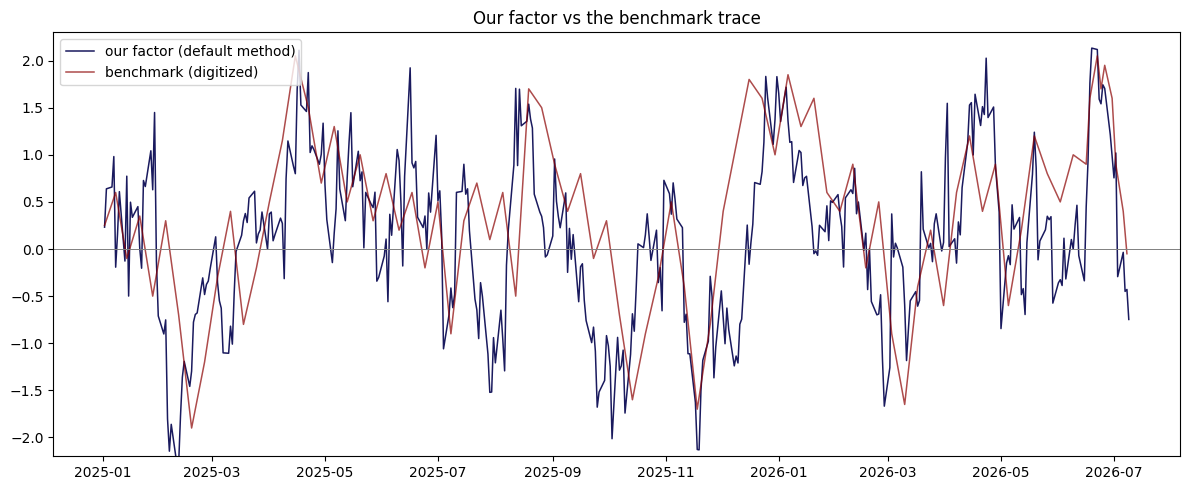

In [3]:
factor = pd.read_csv("factor.csv", index_col=0, parse_dates=True).iloc[:, 0]

def score_against_benchmark(candidate):
    """Return (corr, rmse, n_days) of a candidate series vs the benchmark."""
    both = pd.DataFrame({"cand": candidate, "bench": benchmark}).dropna()
    corr = both["cand"].corr(both["bench"])
    rmse = np.sqrt(((both["cand"] - both["bench"]) ** 2).mean())
    return corr, rmse, len(both)

corr, rmse, n = score_against_benchmark(factor)
fomc_date = pd.Timestamp(2026, 6, 17)

print(f"Default method (halflife=21, level, WTI) over {n} shared days:")
print(f"  correlation vs benchmark: {corr:+.2f}")
print(f"  RMSE                    : {rmse:.2f}")
print(f"  peak after June FOMC    : ours {factor[factor.index >= fomc_date].max():+.2f}"
      f"  benchmark {benchmark[benchmark.index >= fomc_date].max():+.2f}")
print(f"  latest                  : ours {factor.iloc[-1]:+.2f}"
      f"  benchmark {benchmark.iloc[-1]:+.2f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(factor.index, factor.values, color="#1a1a5e", linewidth=1.1,
        label="our factor (default method)")
ax.plot(benchmark.index, benchmark.values, color="darkred", linewidth=1.1,
        alpha=0.7, label="benchmark (digitized)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.2, 2.3)
ax.set_title("Our factor vs the benchmark trace")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("factor_vs_benchmark.png", dpi=120)
plt.show()

### Part B — choose the METHOD that matches best (not the numbers)

The menu — every row is a legitimate construction by itself:

- `ewm_kind`: "21 day exponentially weighted" can mean **halflife=21**
  (slow fade), **span=21** (fast fade), or **com=21** (in between).
- `z_on`: z-score the **level** of each series, or its daily **change**.
- `oil`: WTI (`CL1`) or Brent (`CO1`).

3 × 2 × 2 = **12 candidates**. We score each one against the benchmark
and pick the winner. Because the menu is tiny and every option is
economically sensible, this is model *selection*, not curve fitting —
there aren't enough knobs here to memorize a chart.

In [4]:
raw = bbg.bdh(fl.TICKERS, "PX_LAST",
              pd.Timestamp(2025, 1, 1).date()).ffill().dropna()

results = []
for ewm_kind in ["halflife", "span", "com"]:
    for z_on in ["level", "change"]:
        for oil in ["CL1 Comdty", "CO1 Comdty"]:
            signed_z = fl.build_signed_zscores(raw, ewm_kind=ewm_kind,
                                               z_on=z_on, oil=oil)
            candidate = fl.build_factor(signed_z)  # equal weights, always
            corr, rmse, _ = score_against_benchmark(candidate)
            results.append({"ewm_kind": ewm_kind, "z_on": z_on,
                            "oil": oil.split()[0], "corr": round(corr, 3),
                            "rmse": round(rmse, 3)})

table = pd.DataFrame(results).sort_values("corr", ascending=False)
print(table.to_string(index=False))

best = table.iloc[0]
print(f"\nBest method: ewm_kind={best['ewm_kind']}, z_on={best['z_on']}, "
      f"oil={best['oil']}  (corr {best['corr']:+.2f}, rmse {best['rmse']:.2f})")

ewm_kind   z_on oil   corr  rmse
halflife  level CL1  0.564 0.836
halflife  level CO1  0.563 0.836
     com  level CL1  0.535 0.855
     com  level CO1  0.535 0.854
    span  level CO1  0.413 0.923
    span  level CL1  0.410 0.926
halflife change CO1 -0.017 1.098
halflife change CL1 -0.018 1.101
     com change CO1 -0.027 1.096
     com change CL1 -0.028 1.099
    span change CO1 -0.046 1.085
    span change CL1 -0.046 1.087

Best method: ewm_kind=halflife, z_on=level, oil=CL1  (corr +0.56, rmse 0.84)


**How to read that table on real data:** if one method is clearly ahead
(corr gap > ~0.05), adopt it. If several tie, prefer the simplest
(halflife, level, WTI) — ties mean the choice doesn't matter, so don't
pretend precision. And sanity-check the winner visually below: matching
the *shape* (spike timing, unwind speed) matters more than the corr's
second decimal.

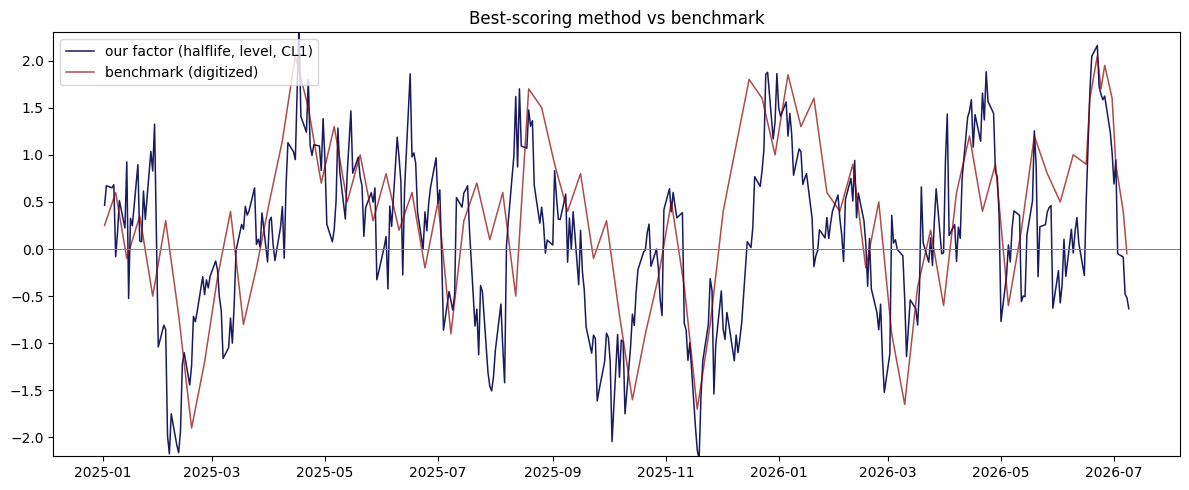

Saved chosen_method.json and refreshed the caches


In [5]:
CHOSEN = {"ewm_kind": best["ewm_kind"], "z_on": best["z_on"],
          "oil": best["oil"] + " Comdty"}

signed_z_best = fl.build_signed_zscores(raw, ewm_kind=CHOSEN["ewm_kind"],
                                        z_on=CHOSEN["z_on"], oil=CHOSEN["oil"])
factor_best = fl.build_factor(signed_z_best)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(factor_best.index, factor_best.values, color="#1a1a5e",
        linewidth=1.1, label=f"our factor ({best['ewm_kind']}, "
                             f"{best['z_on']}, {best['oil']})")
ax.plot(benchmark.index, benchmark.values, color="darkred", linewidth=1.1,
        alpha=0.7, label="benchmark (digitized)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.2, 2.3)
ax.set_title("Best-scoring method vs benchmark")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("factor_vs_benchmark_best.png", dpi=120)
plt.show()

# save the chosen method so live_refresh() reuses it
with open("chosen_method.json", "w") as f:
    json.dump(CHOSEN, f, indent=2)
signed_z_best.to_csv("signed_zscores.csv")
factor_best.to_frame("factor").to_csv("factor.csv")
print("Saved chosen_method.json and refreshed the caches")

### Part C — weight check (diagnostic ONLY, weights stay equal)

Could unequal weights fit the benchmark better? Almost certainly — more
knobs always fit better. That is exactly why we don't do it. Instead we
run a *heavily regularized* fit that is pulled toward equal weights and
read it as a diagnostic:

- fitted weights ≈ 1/6 everywhere  → equal weighting confirmed
- a weight pinned near 0 or huge   → our COMPONENT is probably wrong
  (e.g. the FOMC-pricing proxy), so fix the component, not the weight.

The math: minimize ||Z·w − benchmark||² + λ·||w − w_eq||², whose solution
is one `np.linalg.solve` call. λ controls the pull toward equal weights.

In [6]:
both = signed_z_best.join(benchmark, how="inner").dropna()
Z = both[signed_z_best.columns].values
y = both["benchmark"].values
w_eq = np.full(6, 1 / 6)

lam = 5.0  # strong pull toward equal weights - this is a check, not a fit
n = len(Z)
w_fit = np.linalg.solve(Z.T @ Z + lam * n * np.eye(6),
                        Z.T @ y + lam * n * w_eq)

print(f"{'component':<14}{'equal':>8}{'fitted':>9}")
for name, w in zip(signed_z_best.columns, w_fit):
    flag = "  <-- investigate this component" if abs(w - 1/6) > 0.10 else ""
    print(f"{name:<14}{1/6:>8.2f}{w:>9.2f}{flag}")
print(f"\nfitted weights sum: {w_fit.sum():.2f} (equal-weight sum: 1.00)")

component        equal   fitted
fomc_hike         0.17     0.13
yield_30y         0.17     0.14
infl_swap_5y      0.17     0.13
dxy               0.17     0.13
gold              0.17     0.13
oil               0.17     0.13

fitted weights sum: 0.79 (equal-weight sum: 1.00)


---
### Part D — decomposition: who drove the latest big move?

The factor is an equal-weighted average, so any move decomposes exactly:
`factor_change = sum of (signed_z_change / 6)`. Applied to the
post-June-FOMC peak → today. (In mock mode the planted ground-truth
shares from `bbg.py` are shown alongside as a code check.)

In [7]:
after_fomc = factor_best[factor_best.index >= fomc_date]
peak_date = after_fomc.idxmax()

contribution = (signed_z_best.iloc[-1] - signed_z_best.loc[peak_date]) / 6.0
share = contribution / contribution.sum()

planted = {}
if bbg.MOCK_MODE:
    key_map = {"yield_30y": "30y", "dxy": "dxy", "infl_swap_5y": "swap",
               "fomc_hike": "fomc", "oil": "oil", "gold": "gold"}
    planted = {name: bbg._UNWIND_SHARES[key] for name, key in key_map.items()}

print(f"Move from peak ({peak_date.date()}) to latest: "
      f"{contribution.sum():+.2f}\n")
print(f"{'component':<14}{'share':>8}" + ("{:>10}".format("planted") if planted else ""))
for name in share.sort_values().index:
    line = f"{name:<14}{share[name]:>7.0%}"
    if planted:
        line += f"{planted[name]:>9.0%}"
    print(line)

Move from peak (2026-06-22) to latest: -2.79

component        share   planted
gold              11%       3%
fomc_hike         16%      16%
oil               16%      16%
dxy               18%      17%
infl_swap_5y      19%      17%
yield_30y         19%      31%


### Part E — AR(1) forecast, extended

The factor is a z-score → mean-reverting by construction → the simplest
honest model is AR(1): `tomorrow = a + b·today + noise`. From `b` we get
the shock half-life `ln(0.5)/ln(b)`. Uncertainty at k steps ahead is
`noise_std · sqrt((1−b^2k)/(1−b²))`. We wrap it in a function so the
live refresh below can reuse it, and extend the horizon to 3 months.

In [8]:
def ar1_forecast(series, horizon):
    """Fit AR(1) and forecast. Returns (future_dates, path, spread, info)."""
    y = series.dropna()
    b, a = np.polyfit(y.values[:-1], y.values[1:], 1)
    noise_std = (y.values[1:] - (a + b * y.values[:-1])).std()

    path, spread = [], []
    value = y.iloc[-1]
    for k in range(1, horizon + 1):
        value = a + b * value
        path.append(value)
        spread.append(noise_std * np.sqrt((1 - b ** (2 * k)) / (1 - b ** 2)))

    future_dates = pd.bdate_range(y.index[-1], periods=horizon + 1)[1:]
    info = {"a": a, "b": b, "noise_std": noise_std,
            "half_life": np.log(0.5) / np.log(b),
            "long_run_mean": a / (1 - b)}
    return future_dates, np.array(path), np.array(spread), info


HORIZON = 63  # ~3 months of business days
fdates, path, spread, info = ar1_forecast(factor_best, HORIZON)

print(f"AR(1): tomorrow = {info['a']:+.4f} + {info['b']:.4f} * today")
print(f"Shock half-life : {info['half_life']:.1f} business days")
print(f"Long-run mean   : {info['long_run_mean']:+.2f}")
print(f"Forecast in {HORIZON} days: {path[-1]:+.2f}")

AR(1): tomorrow = +0.0138 + 0.8581 * today
Shock half-life : 4.5 business days
Long-run mean   : +0.10
Forecast in 63 days: +0.10


### Part F — the live update call

`live_refresh()` is the whole pipeline in one function: pull Bloomberg
data **up to today**, rebuild the factor with the chosen method, overlay
the benchmark for the period they share, and extrapolate forward with
the AR(1) fan. Run this one cell any day for a current picture.

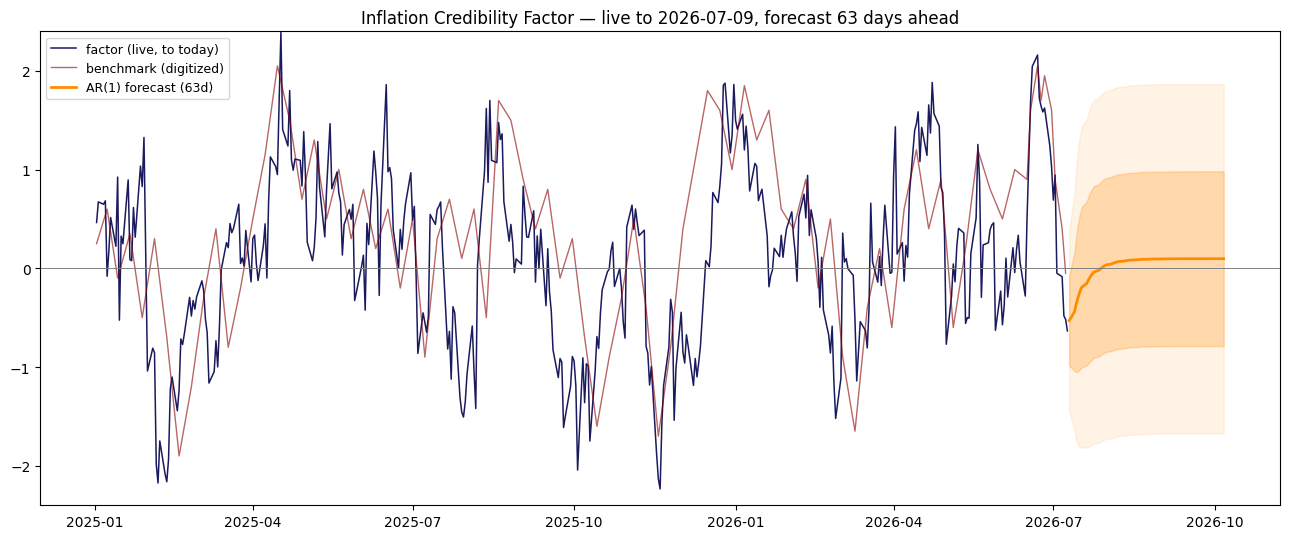

As of 2026-07-09: factor = -0.63
Forecast 63d ahead : +0.10 (reverting toward +0.10, half-life 4.5d)


In [9]:
def live_refresh(horizon=63):
    """Pull to today, rebuild, plot history + benchmark + forecast fan."""
    with open("chosen_method.json") as f:
        method = json.load(f)

    raw = bbg.bdh(fl.TICKERS, "PX_LAST",
                  pd.Timestamp(2025, 1, 1).date()).ffill().dropna()
    signed_z = fl.build_signed_zscores(raw, ewm_kind=method["ewm_kind"],
                                       z_on=method["z_on"], oil=method["oil"])
    live = fl.build_factor(signed_z)

    fdates, path, spread, info = ar1_forecast(live, horizon)

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(live.index, live.values, color="#1a1a5e", linewidth=1.1,
            label="factor (live, to today)")
    ax.plot(benchmark.index, benchmark.values, color="darkred",
            linewidth=1.0, alpha=0.6, label="benchmark (digitized)")
    ax.plot(fdates, path, color="darkorange", linewidth=2,
            label=f"AR(1) forecast ({horizon}d)")
    ax.fill_between(fdates, path - spread, path + spread,
                    color="darkorange", alpha=0.25)
    ax.fill_between(fdates, path - 2 * spread, path + 2 * spread,
                    color="darkorange", alpha=0.10)
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_ylim(-2.4, 2.4)
    ax.set_title(f"Inflation Credibility Factor — live to "
                 f"{live.index[-1].date()}, forecast {horizon} days ahead")
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig("factor_live.png", dpi=120)
    plt.show()

    print(f"As of {live.index[-1].date()}: factor = {live.iloc[-1]:+.2f}")
    print(f"Forecast {horizon}d ahead : {path[-1]:+.2f} "
          f"(reverting toward {info['long_run_mean']:+.2f}, "
          f"half-life {info['half_life']:.1f}d)")
    return live


live_factor = live_refresh()

### Reading all of this

- **Match first:** on real data, iterate Parts A–B until the overlay is
  visually right (spike timing, unwind speed, levels). Refine benchmark
  anchors if a region looks off — the checker must be fair before the
  score means anything.
- **Don't chase 100%:** the benchmark is digitized by eye from an image;
  a corr around 0.9 with matching peaks IS "exactly right" within the
  noise of reading a chart. Squeezing further = fitting digitization
  error, which is overfitting with extra steps.
- **Then predict:** the fan is the "no news" base case — mean reversion
  with honest error bands. What breaks the base case is policy action:
  watch the `fomc_hike` component for follow-through, oil and swaps for
  renewed inflation pressure.